In [1]:
!pip install torch transformers datasets scikit-learn pandas numpy matplotlib seaborn wordcloud spacy



[notice] A new release of pip is available: 25.2 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from datasets import load_dataset
from wordcloud import WordCloud
from collections import Counter

C:\Users\hp\AppData\Local\Programs\Python\Python312\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
from datasets import load_dataset

In [4]:
from datasets import load_dataset
import pandas as pd

# Reload dataset
dataset = load_dataset("tasksource/logical-fallacy")

# Convert to dataframes
df_train = pd.DataFrame(dataset['train'])
df_test = pd.DataFrame(dataset['test'])
df_dev = pd.DataFrame(dataset['dev'])

# Rename columns
df_train = df_train.rename(columns={'source_article': 'text', 'logical_fallacies': 'label'})
df_test = df_test.rename(columns={'source_article': 'text', 'logical_fallacies': 'label'})
df_dev = df_dev.rename(columns={'source_article': 'text', 'logical_fallacies': 'label'})

print("Train size:", len(df_train))
print("Test size:", len(df_test))
print("Dev size:", len(df_dev))
print("\nLabel distribution:\n", df_train['label'].value_counts())

Train size: 2680
Test size: 511
Dev size: 570

Label distribution:
 label
faulty generalization     401
intentional               321
ad hominem                289
appeal to emotion         217
false causality           212
ad populum                209
fallacy of credibility    200
fallacy of logic          176
fallacy of relevance      175
false dilemma             143
circular reasoning        140
fallacy of extension      139
equivocation               58
Name: count, dtype: int64


In [5]:
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud

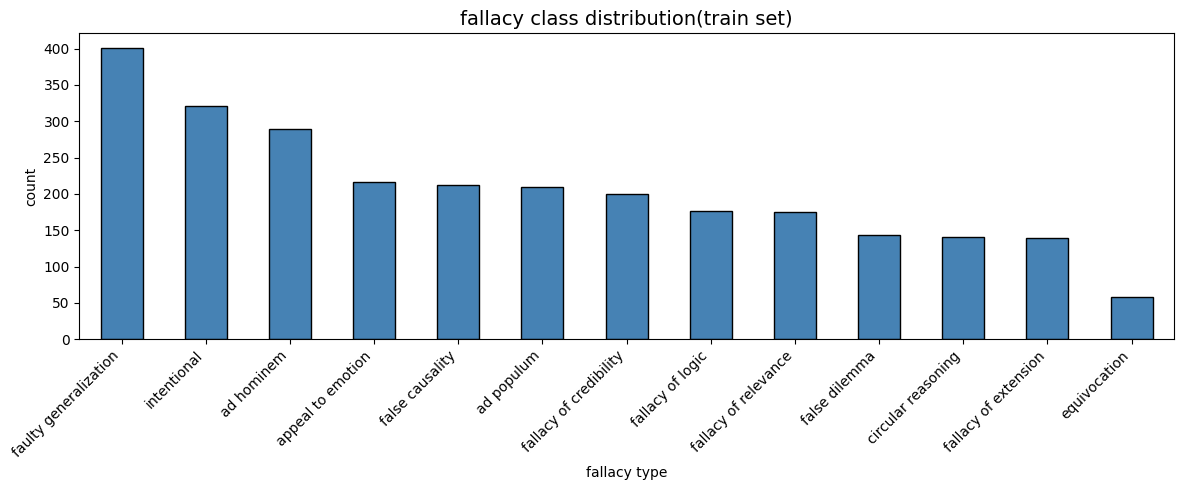

In [6]:
plt.figure(figsize=(12,5))
df_train['label'].value_counts().plot(kind='bar',color='steelblue',edgecolor='black')
plt.title('fallacy class distribution(train set)',fontsize=14)
plt.xlabel('fallacy type')
plt.ylabel('count')
plt.xticks(rotation=45,ha='right')
plt.tight_layout()
plt.savefig('class_distribution.png',dpi=150)
plt.show()


Text length stats
average:28.0words
max:188words
min:3words
median:23.0words


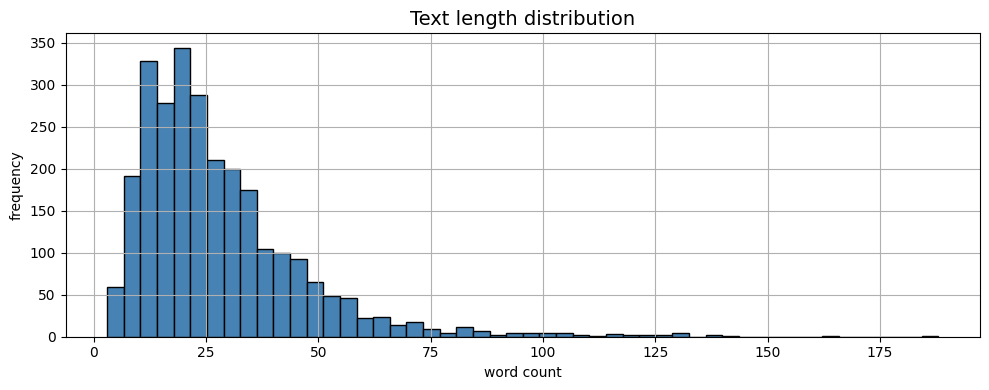

In [7]:
#text length analysis
df_train['text_length']=df_train['text'].apply(lambda x:len(x.split()))
print("Text length stats")
print(f"average:{df_train['text_length'].mean():.1f}words")
print(f"max:{df_train['text_length'].max()}words")
print(f"min:{df_train['text_length'].min()}words")
print(f"median:{df_train['text_length'].median()}words")
plt.figure(figsize=(10,4))
df_train['text_length'].hist(bins=50,color='steelblue',edgecolor='black')
plt.title('Text length distribution',fontsize=14)
plt.xlabel('word count')
plt.ylabel('frequency')
plt.tight_layout()
plt.savefig('text_length.png',dpi=150)
plt.show()



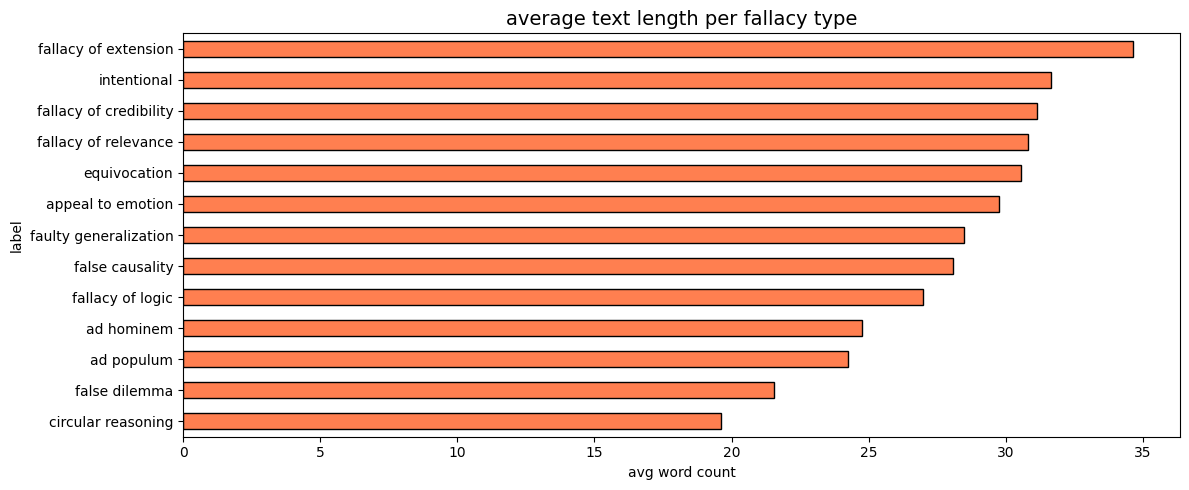

In [8]:
#average text length per fallacy
plt.figure(figsize=(12,5))
df_train.groupby('label')['text_length'].mean().sort_values().plot(
    kind='barh',color='coral',edgecolor='black'
)
plt.title('average text length per fallacy type',fontsize=14)
plt.xlabel('avg word count')
plt.tight_layout()
plt.savefig('length_per_class.png',dpi=150)
plt.show()


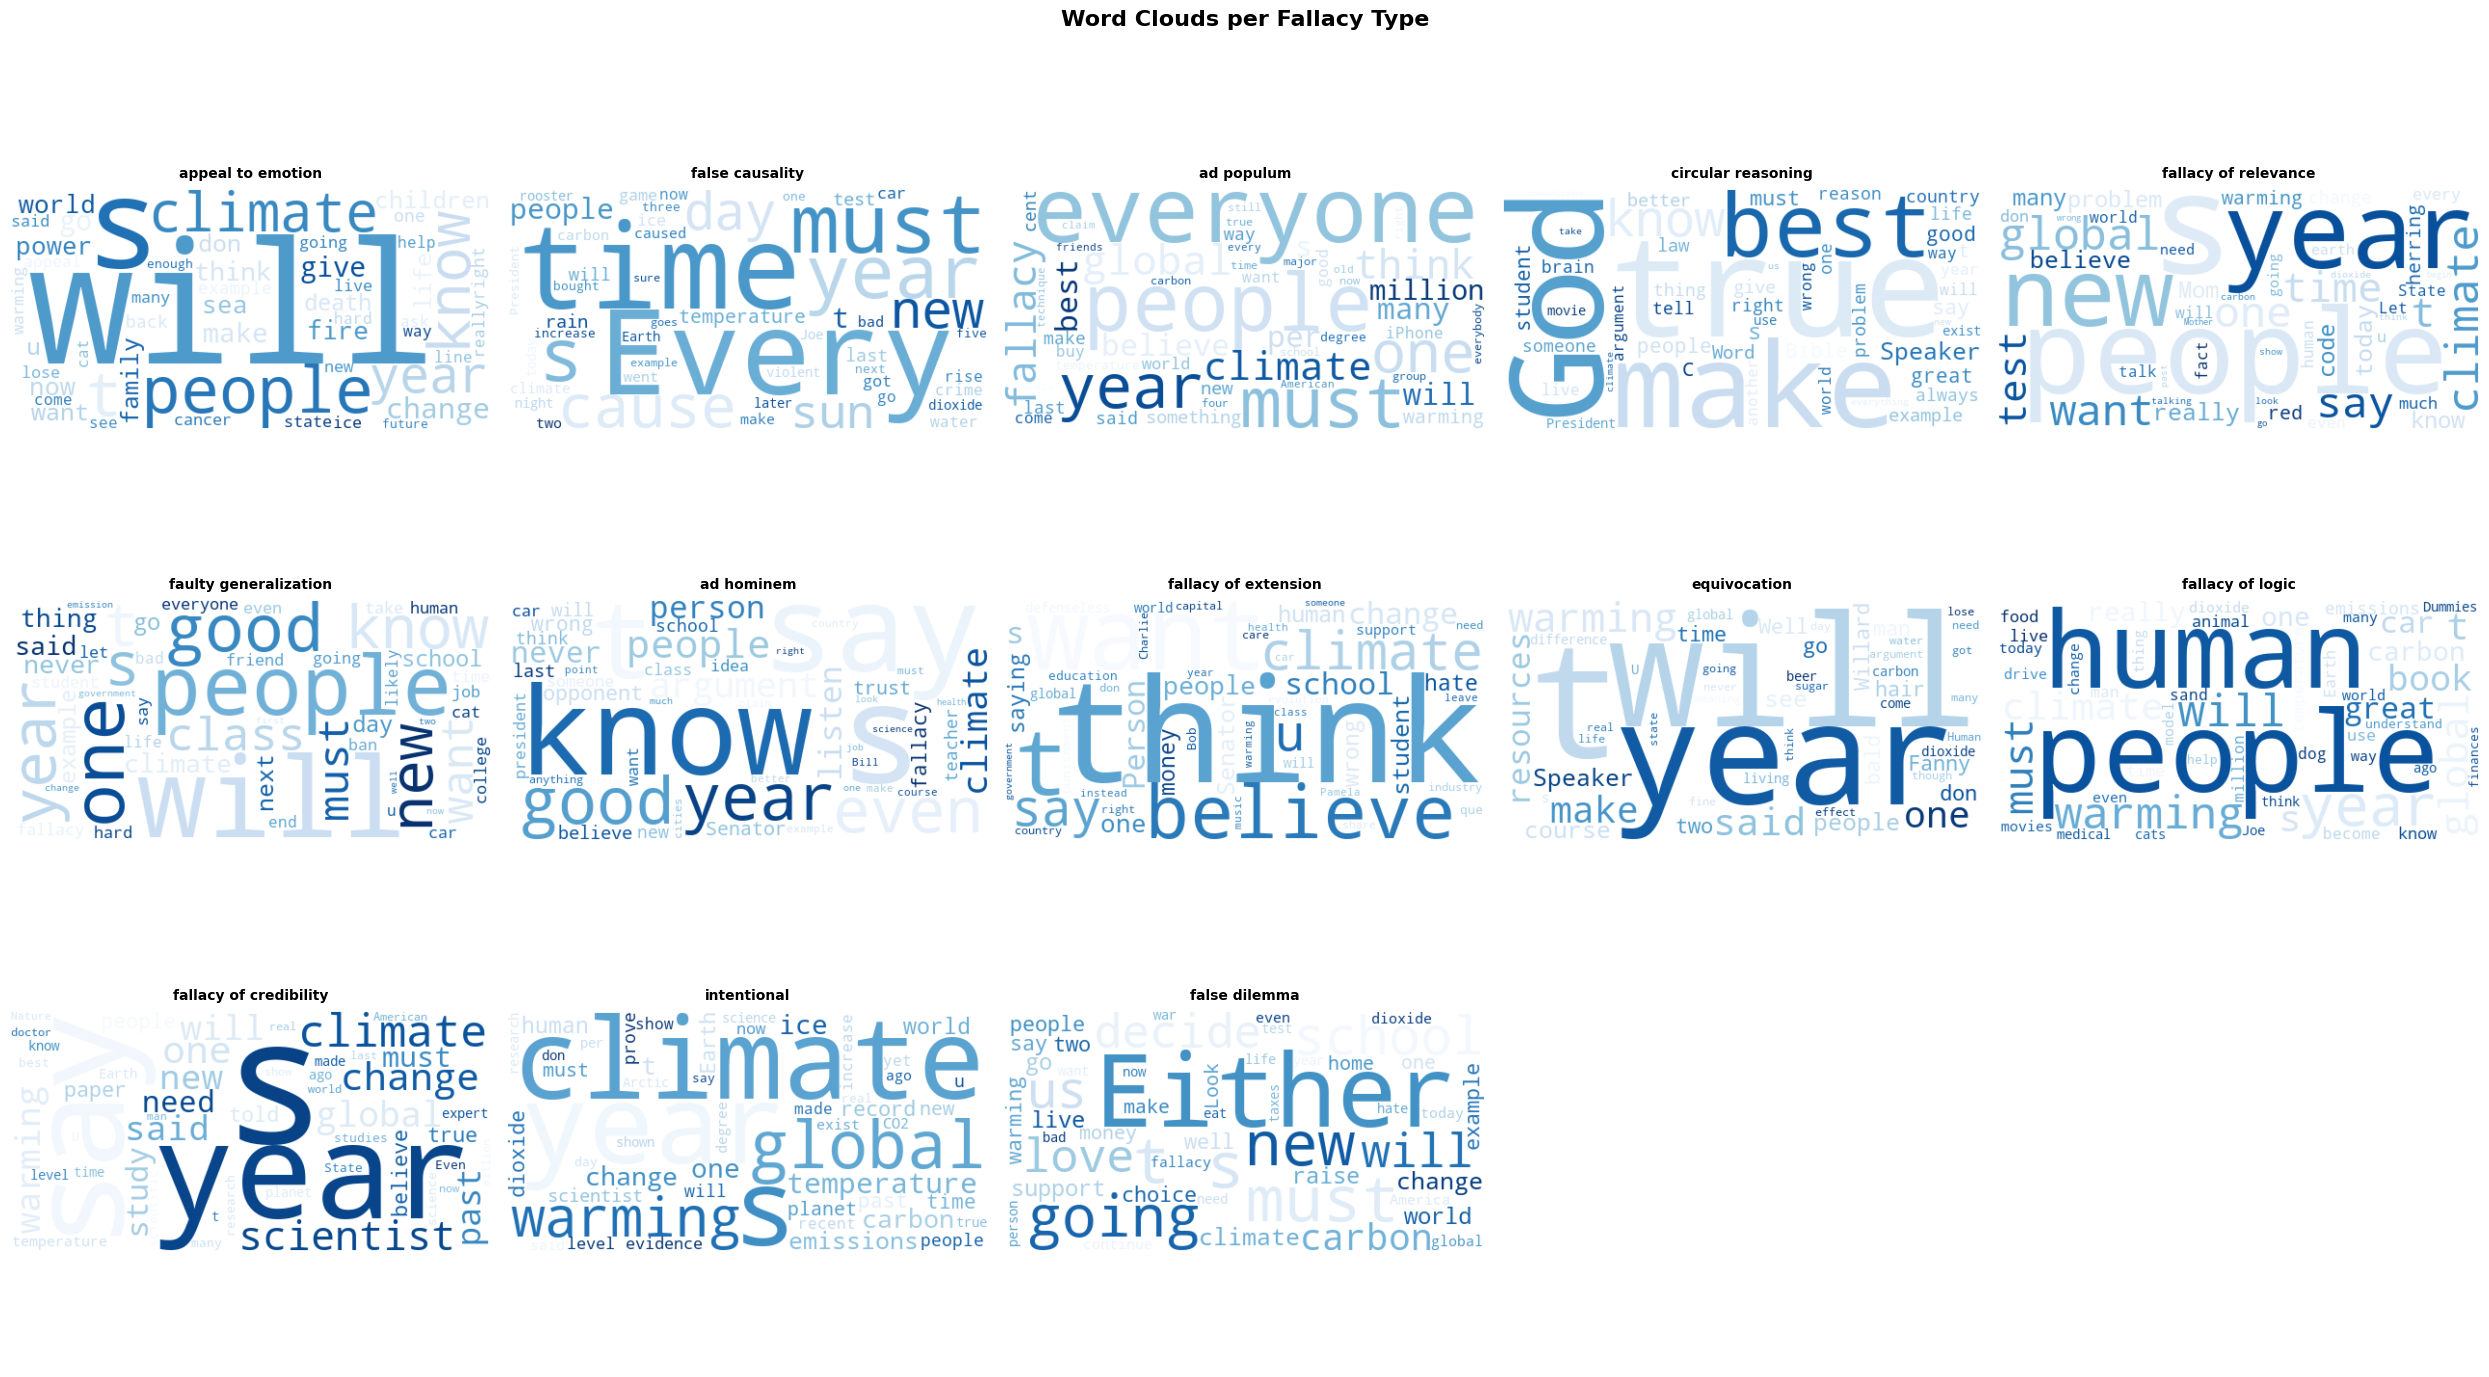

✅ Done!


In [17]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt

df_train['label'] = df_train['label'].str.strip()

labels = df_train['label'].unique().tolist()

fig, axes = plt.subplots(3, 5, figsize=(25, 14))
axes = axes.flatten()

for i, label in enumerate(labels):
    subset = df_train[df_train['label'] == label]['text'].tolist()
    texts = " ".join(subset)
    
    wc = WordCloud(
        width=500,
        height=250,
        background_color='white',
        colormap='Blues',
        max_words=50,
        collocations=False 
    ).generate(texts)
    
    axes[i].imshow(wc, interpolation='bilinear')
    axes[i].set_title(label, fontsize=10, fontweight='bold', pad=8)
    axes[i].axis('off')

for j in range(len(labels), len(axes)):
    axes[j].axis('off')

plt.suptitle('Word Clouds per Fallacy Type', fontsize=16, fontweight='bold')
plt.tight_layout(rect=[0, 0, 1, 0.97])
plt.savefig('wordclouds_fixed.png', dpi=150, bbox_inches='tight')
plt.show()
print(" Done!")

In [13]:
# Check exact label values
print(repr(df_train['label'].unique()))
print(df_train['label'].value_counts())

array(['appeal to emotion', 'false causality', 'ad populum',
       'circular reasoning', 'fallacy of relevance',
       'faulty generalization', 'ad hominem', 'fallacy of extension',
       'equivocation', 'fallacy of logic', 'fallacy of credibility',
       'intentional', 'false dilemma'], dtype=object)
label
faulty generalization     401
intentional               321
ad hominem                289
appeal to emotion         217
false causality           212
ad populum                209
fallacy of credibility    200
fallacy of logic          176
fallacy of relevance      175
false dilemma             143
circular reasoning        140
fallacy of extension      139
equivocation               58
Name: count, dtype: int64
